# Week 1 — Run it, then discover a real truth yourself

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/khaled-dragon/ML-intern/blob/main/notebooks/01_first_look_and_discovery.ipynb)

By the end of this notebook you will have:
1. **Run a real ML pipeline** on real (anonymized) search data and watched a learned model beat a hand-written rule.
2. **Rediscovered a real finding yourself** in ~10 lines of pandas.

No prior ML needed. Everything runs on the small anonymized dataset that ships with this repo — no credentials, no private data.

## 0. Setup (Colab or local)
On Colab this clones the repo and installs requirements. Locally it just moves to the repo root.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # move from notebooks/ to the repo root

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## 1. Run the whole pipeline

This runs `scripts/run_all.py`: prepare features → baseline rule → train 3 models → evaluate → PDF.
It takes ~1 minute on the 30,000-row sample.

In [2]:
# Watch it work — each of the 5 steps prints live as it runs (~1 minute total).
!{sys.executable} scripts/run_all.py



▶ Step 1/5 — Prepare features — clean the data, build the feature vector, define the label
Prepared 30,000 rows from 30,000 raw rows
Wrote /content/flyrank-ml-internship-starter/data/processed/refresh_feature_vector.csv

▶ Step 2/5 — Baseline — a transparent hand-written rule to beat
Wrote baseline queue: /content/flyrank-ml-internship-starter/data/processed/baseline_refresh_queue.csv
Top-50 declining rate (full data, not the evaluated holdout Precision@50): 0.340

▶ Step 3/5 — Train — logistic regression, decision tree, random forest (client-holdout split)
Trained 3 models on 30,000 rows
Split strategy: client_holdout
Best model: random_forest
Wrote predictions: /content/flyrank-ml-internship-starter/data/processed/model_predictions.csv
Wrote model results: /content/flyrank-ml-internship-starter/outputs/model_results.json

▶ Step 4/5 — Evaluate — ranked refresh queue, charts, and the Markdown report
Wrote final refresh queue: /content/flyrank-ml-internship-starter/outputs/refresh_que

### What just happened?
The pipeline ranked every page for "refresh review" two ways: a **hand-written rule baseline** and a **learned model**. Let's compare them on **Precision@50** — of the top 50 pages each says to fix first, how many are actually declining?

In [3]:
import json
res = json.load(open("outputs/model_results.json"))

base = res["baseline"]["baseline_precision_at_50"]
rf   = res["models"]["random_forest"]["precision_at_50"]

print(f"Hand-written rule  Precision@50: {base:.3f}   (~{round(base*50)} of the top 50 right)")
print(f"Random forest      Precision@50: {rf:.3f}   (~{round(rf*50)} of the top 50 right)")
print(f"\nThe learned model roughly {rf/base:.1f}x the rule on this metric.")
print("Validation split used:", res["split_strategy"], "(pages from a client are never in both train and test)")

Hand-written rule  Precision@50: 0.240   (~12 of the top 50 right)
Random forest      Precision@50: 0.740   (~37 of the top 50 right)

The learned model roughly 3.1x the rule on this metric.
Validation split used: client_holdout (pages from a client are never in both train and test)


You just ran a real ML system on real search data and saw a learned ranking beat a fixed rule. Now open `outputs/model_report.md` and skim it — that Markdown report is the *shape* of what your own capstone should produce.

## 2. Discover a real truth yourself

The safest, most satisfying early wins are **things you find in the data** — un-leakable, and they *are* the core lesson. Run the three cells below. Each is ~10 lines of pandas and each overturns a common SEO belief.

Every number is **computed live from the shipped CSV** — nothing is hardcoded.

In [4]:
import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.shape[0], "rows,", df.shape[1], "columns")
df.head(3)

30000 rows, 44 columns


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9


### Discovery A — "High search volume means more traffic." Does it?

In [5]:
corr = df["search_volume"].corr(df["impressions_90d"])
print(f"Correlation between search_volume and impressions_90d: {corr:.3f}")
print("Near zero -> keyword search volume barely predicts the traffic a page actually gets.")

Correlation between search_volume and impressions_90d: 0.001
Near zero -> keyword search volume barely predicts the traffic a page actually gets.


### Discovery B — the CTR cliff by position
Click-through rate is not flat: it collapses as you move down the results.

position_tier
page_1      0.3548
top_3       0.3341
striking    0.2558
page_3_5    0.1424
deep        0.0554


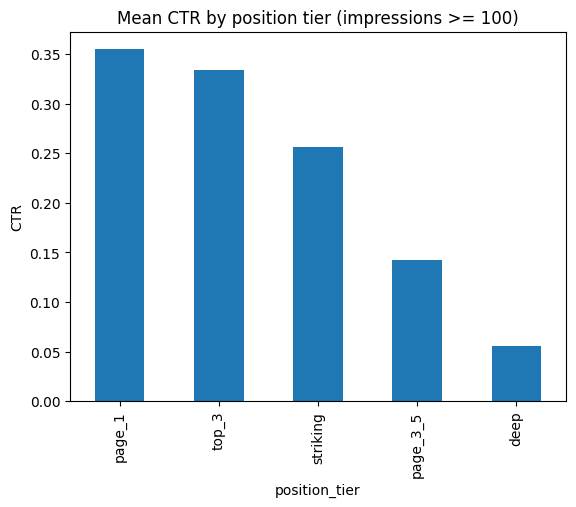

In [6]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos = visible.groupby("position_tier")["ctr"].mean().sort_values(ascending=False)
print(ctr_by_pos.round(4).to_string())
ctr_by_pos.plot(kind="bar", title="Mean CTR by position tier (impressions >= 100)", ylabel="CTR");

### Discovery C — is longer content the lever?
Compare word count for **declining** vs **growing** pages.

In [7]:
wc = df.groupby("trend_direction")["word_count"].median()
print(wc.round(0).to_string())
print("\n'down' vs 'up' pages have almost the same median word count -> length is not the lever.")

trend_direction
down      2909.0
flat      2698.0
new       2239.0
stable    2912.0
up        2848.0

'down' vs 'up' pages have almost the same median word count -> length is not the lever.


## 3. 🔧 Your turn

Pick **one** of these and write a few lines below. This is your Week-1 discovery — you'll reference it in your Week-1 research-question write-up (on the InternHQ board).

- Redo Discovery A but only for pages with `impressions_90d > 0` — does the correlation change?
- In Discovery B, which `content_type` has the worst CTR *at the same position tier*?
- Find another belief to test: does `content_age_days` relate to `trend_direction`? Does `avg_position` relate to `ctr`?

**Rules:** describe what you observe as *observed / directional* — never "I proved Google's algorithm." Keep client data out of anything you publish.

### '##########################################################'

### Discovery_A **extended** - "High search volume means more traffic." Does it?

In [16]:
# Discovery A revisited: only pages with real impressions (impressions>0)
visible_pages = df[df["impressions_90d"] > 0]
corr_visible = visible_pages["search_volume"].corr(visible_pages["impressions_90d"])
print(f"Correlation (impressions_90d > 0 only): {corr_visible:.3f}")
print(f"Original correlation (all rows): {df['search_volume'].corr(df['impressions_90d']):.3f}")

Correlation (impressions_90d > 0 only): 0.001
Original correlation (all rows): 0.001


**My discovery (Discovery_A):**
Filtering to only pages with impressions_90d > 0 didn't change the correlation at all
(0.001 in both cases). This means the near-zero relationship between **search_volume** and
**impressions_90d** isn't caused by "dead" pages dragging the number down - it holds even
among pages that are actually getting seen. Observed / directional: keyword search volume
alone is not a reliable signal for how much real traffic a page will get.

### Discovery_B **extended**: worst content_type at each position tier

position_tier  content_type      
top_3          comparison article    0.0000
deep           feedly article        0.0440
               keyword article       0.0555
page_3_5       comparison article    0.0940
page_1         comparison article    0.1412
page_3_5       keyword article       0.1427
striking       comparison article    0.1474
page_3_5       feedly article        0.1656
striking       keyword article       0.2559
top_3          keyword article       0.3104
page_1         keyword article       0.3458
striking       feedly article        0.3580
page_1         feedly article        0.9048
top_3          feedly article        2.9000

--- Worst content_type per position tier ---
position_tier
deep                (deep, feedly article)
page_1        (page_1, comparison article)
page_3_5    (page_3_5, comparison article)
striking    (striking, comparison article)
top_3          (top_3, comparison article)
Name: ctr, dtype: object


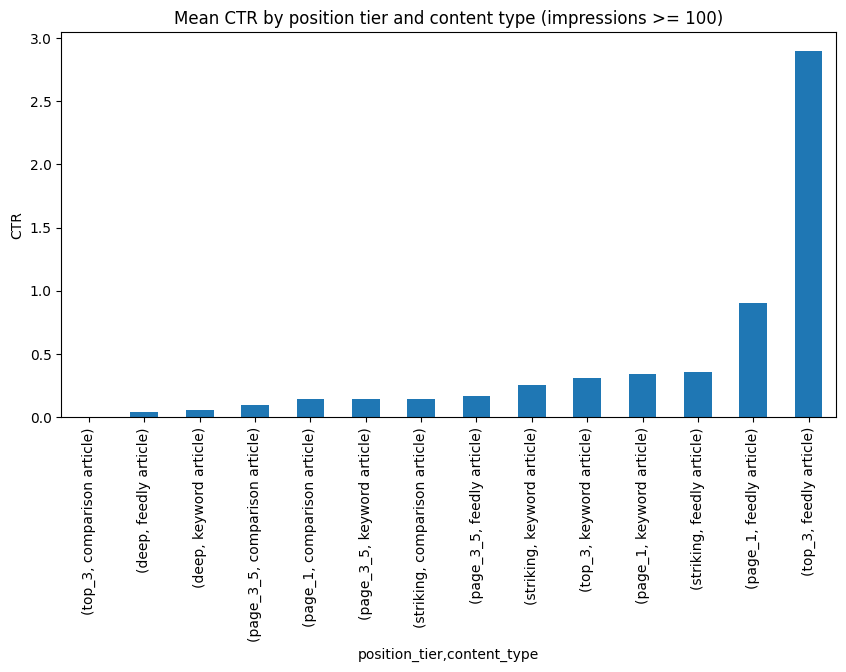

In [20]:
visible = df[df["impressions_90d"] >= 100]
ctr_by_pos_type = visible.groupby(["position_tier", "content_type"])["ctr"].mean().sort_values()
print(ctr_by_pos_type.round(4).to_string())
ctr_by_pos_type.plot(kind="bar", figsize=(10,5), title="Mean CTR by position tier and content type (impressions >= 100)", ylabel="CTR");

print("\n--- Worst content_type per position tier ---")
worst_per_tier = visible.groupby(["position_tier", "content_type"])["ctr"].mean().groupby("position_tier").idxmin()
print(worst_per_tier)

position_tier
deep        0.044000
page_1      0.141239
page_3_5    0.093968
striking    0.147368
top_3       0.000000
Name: ctr, dtype: float64


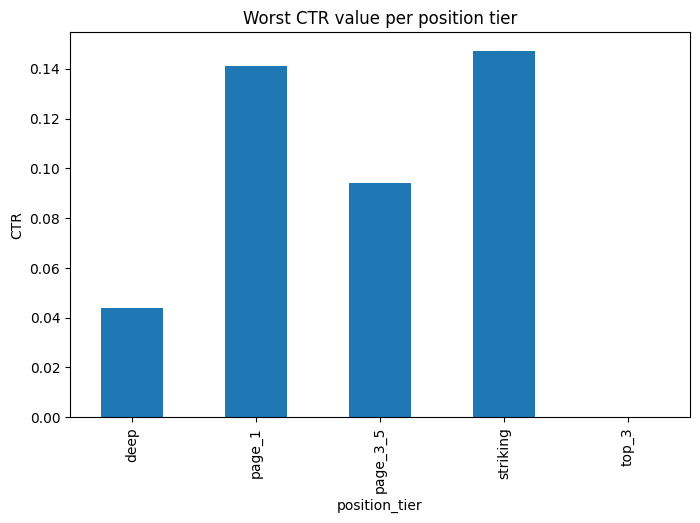

In [23]:
worst_ctr_values = visible.groupby(["position_tier", "content_type"])["ctr"].mean().groupby("position_tier").min()
print(worst_ctr_values)
worst_ctr_values.plot(kind="bar", figsize=(8,5), title="Worst CTR value per position tier", ylabel="CTR");

**My discovery (Discovery_B):**
I grouped CTR by **position_tier** and **content_type** together instead of just
position_tier on its own, to see if some formats get clicked less even when
they land in the same spot. Comparison articles came out with the lowest CTR
in almost every tier, from **top_3** down to **page_3_5**, and only lost that spot
in the deep tier where feedly article was worse. Observed / directional:
ranking well doesn't seem to be the whole story here, comparison articles
get fewer clicks than other formats even at the same position, which points
to the format itself (maybe the title or snippet) rather than where it ranks.

### Discovery_C **extended**: does content age relate to trend direction?

trend_direction
down      216.0
flat      231.0
new       279.0
stable    300.0
up        292.0


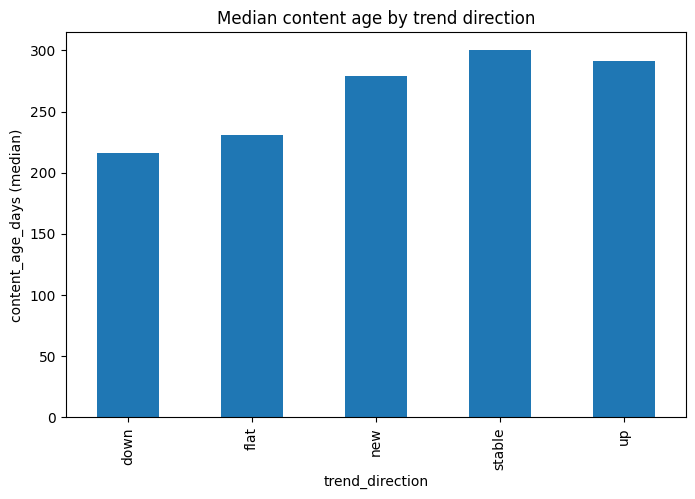

In [24]:
age_by_trend = df.groupby("trend_direction")["content_age_days"].median()
print(age_by_trend.round(0).to_string())

age_by_trend.plot(kind="bar", figsize=(8,5), title="Median content age by trend direction", ylabel="content_age_days (median)");

**My discovery (Discovery_C):**
I grouped **content_age_days** by **trend_direction** to see if declining pages tend
to be older, since "stale content" is a common assumption behind why pages
lose traffic. The numbers actually went the other way: down pages had the
lowest median age **(216 days)**, while stable and up pages were older (300 and
292 days). Observed / directional: declining pages aren't older on average,
they're actually younger, so content age alone doesn't explain why a page
is trending down.